# Transferring of Cell Types from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 18th December 2024\
**Last modified date:** 9th January 2025

#### **Objective**

This notebook outlines the process for transferring cell type annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.

#### **Datasets**

We apply the transfer of cell type labels from the Gut Cell Atlas to the following studies:

- **E-MTAB-8901** (Elementaite et al., 2021) - Fetal developing gut
- **E-MTAB-9536** (Elementaite et al., 2021) - Fetal developing gut
- **E-MTAB-9543** (Elementaite et al., 2021) - Adult gut
- **E-MTAB-9489** (Holloway et al., 2021) - Fetal developing gut
- **E-MTAB-9720** (Holloway et al., 2021) - Fetal enteroids

#### **Methodology**

1. **Dimensionality Reduction Using`scVI`**

   - The `scVI` pipeline is employed to generate a lower-dimensional latent space representation of the cells. This step is crucial for capturing the shared biological signals and mitigating batch effects across datasets.

2. **Cell Type Classification with `scANVI`**

   - We use the semi-supervised classifier network `scANVI` to classify unlabeled cells. By leveraging prior knowledge from the annotated Gut Cell Atlas, `scANVI` predicts cell types for previously unannotated cells.

3. **Uncertainty Analysis**

   - We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.

4. **Model Performance Evaluation**

   - Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
from pywaffle import Waffle
import matplotlib.pyplot as plt
import seaborn as sns
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

2025-01-10 10:01:41.160720: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-10 10:01:41.160765: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-10 10:01:41.160793: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-10 10:01:41.560059: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [7]:
timestamp

'10012025_100142'

## Upload data

In [ ]:
adata = sc.read_h5ad('integration_of_remapped_data/gut_hs_merged_datasets_AM_18122024_131905_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [9]:
X_is_raw(adata)

True

In [10]:
adata_raw = adata.copy()

## Extract highly variable genes

In [11]:
adata.layers["counts"] = adata.X.copy()

In [12]:
sc.pp.highly_variable_genes(
    adata,
    flavor = "seurat_v3",
    n_top_genes = 5000,
    layer = "counts",
    batch_key = "ArrayExpress_ID",
    subset = True,
    span = 1
)
adata

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


AnnData object with n_obs × n_vars = 402343 × 5000
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

## Run scVI

In [13]:
adata.layers['counts'] = adata.X.copy()

In [14]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'ArrayExpress_ID'],
                              labels_key = "category", 
                              layer = 'counts')

In [15]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 15, 
                            n_hidden = 128,
                            n_layers = 2, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [16]:
scvi_model.train(400, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True, 
                accelerator = "gpu",
                devices = [0])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 940.792. Signaling Trainer to stop.


In [17]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [18]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

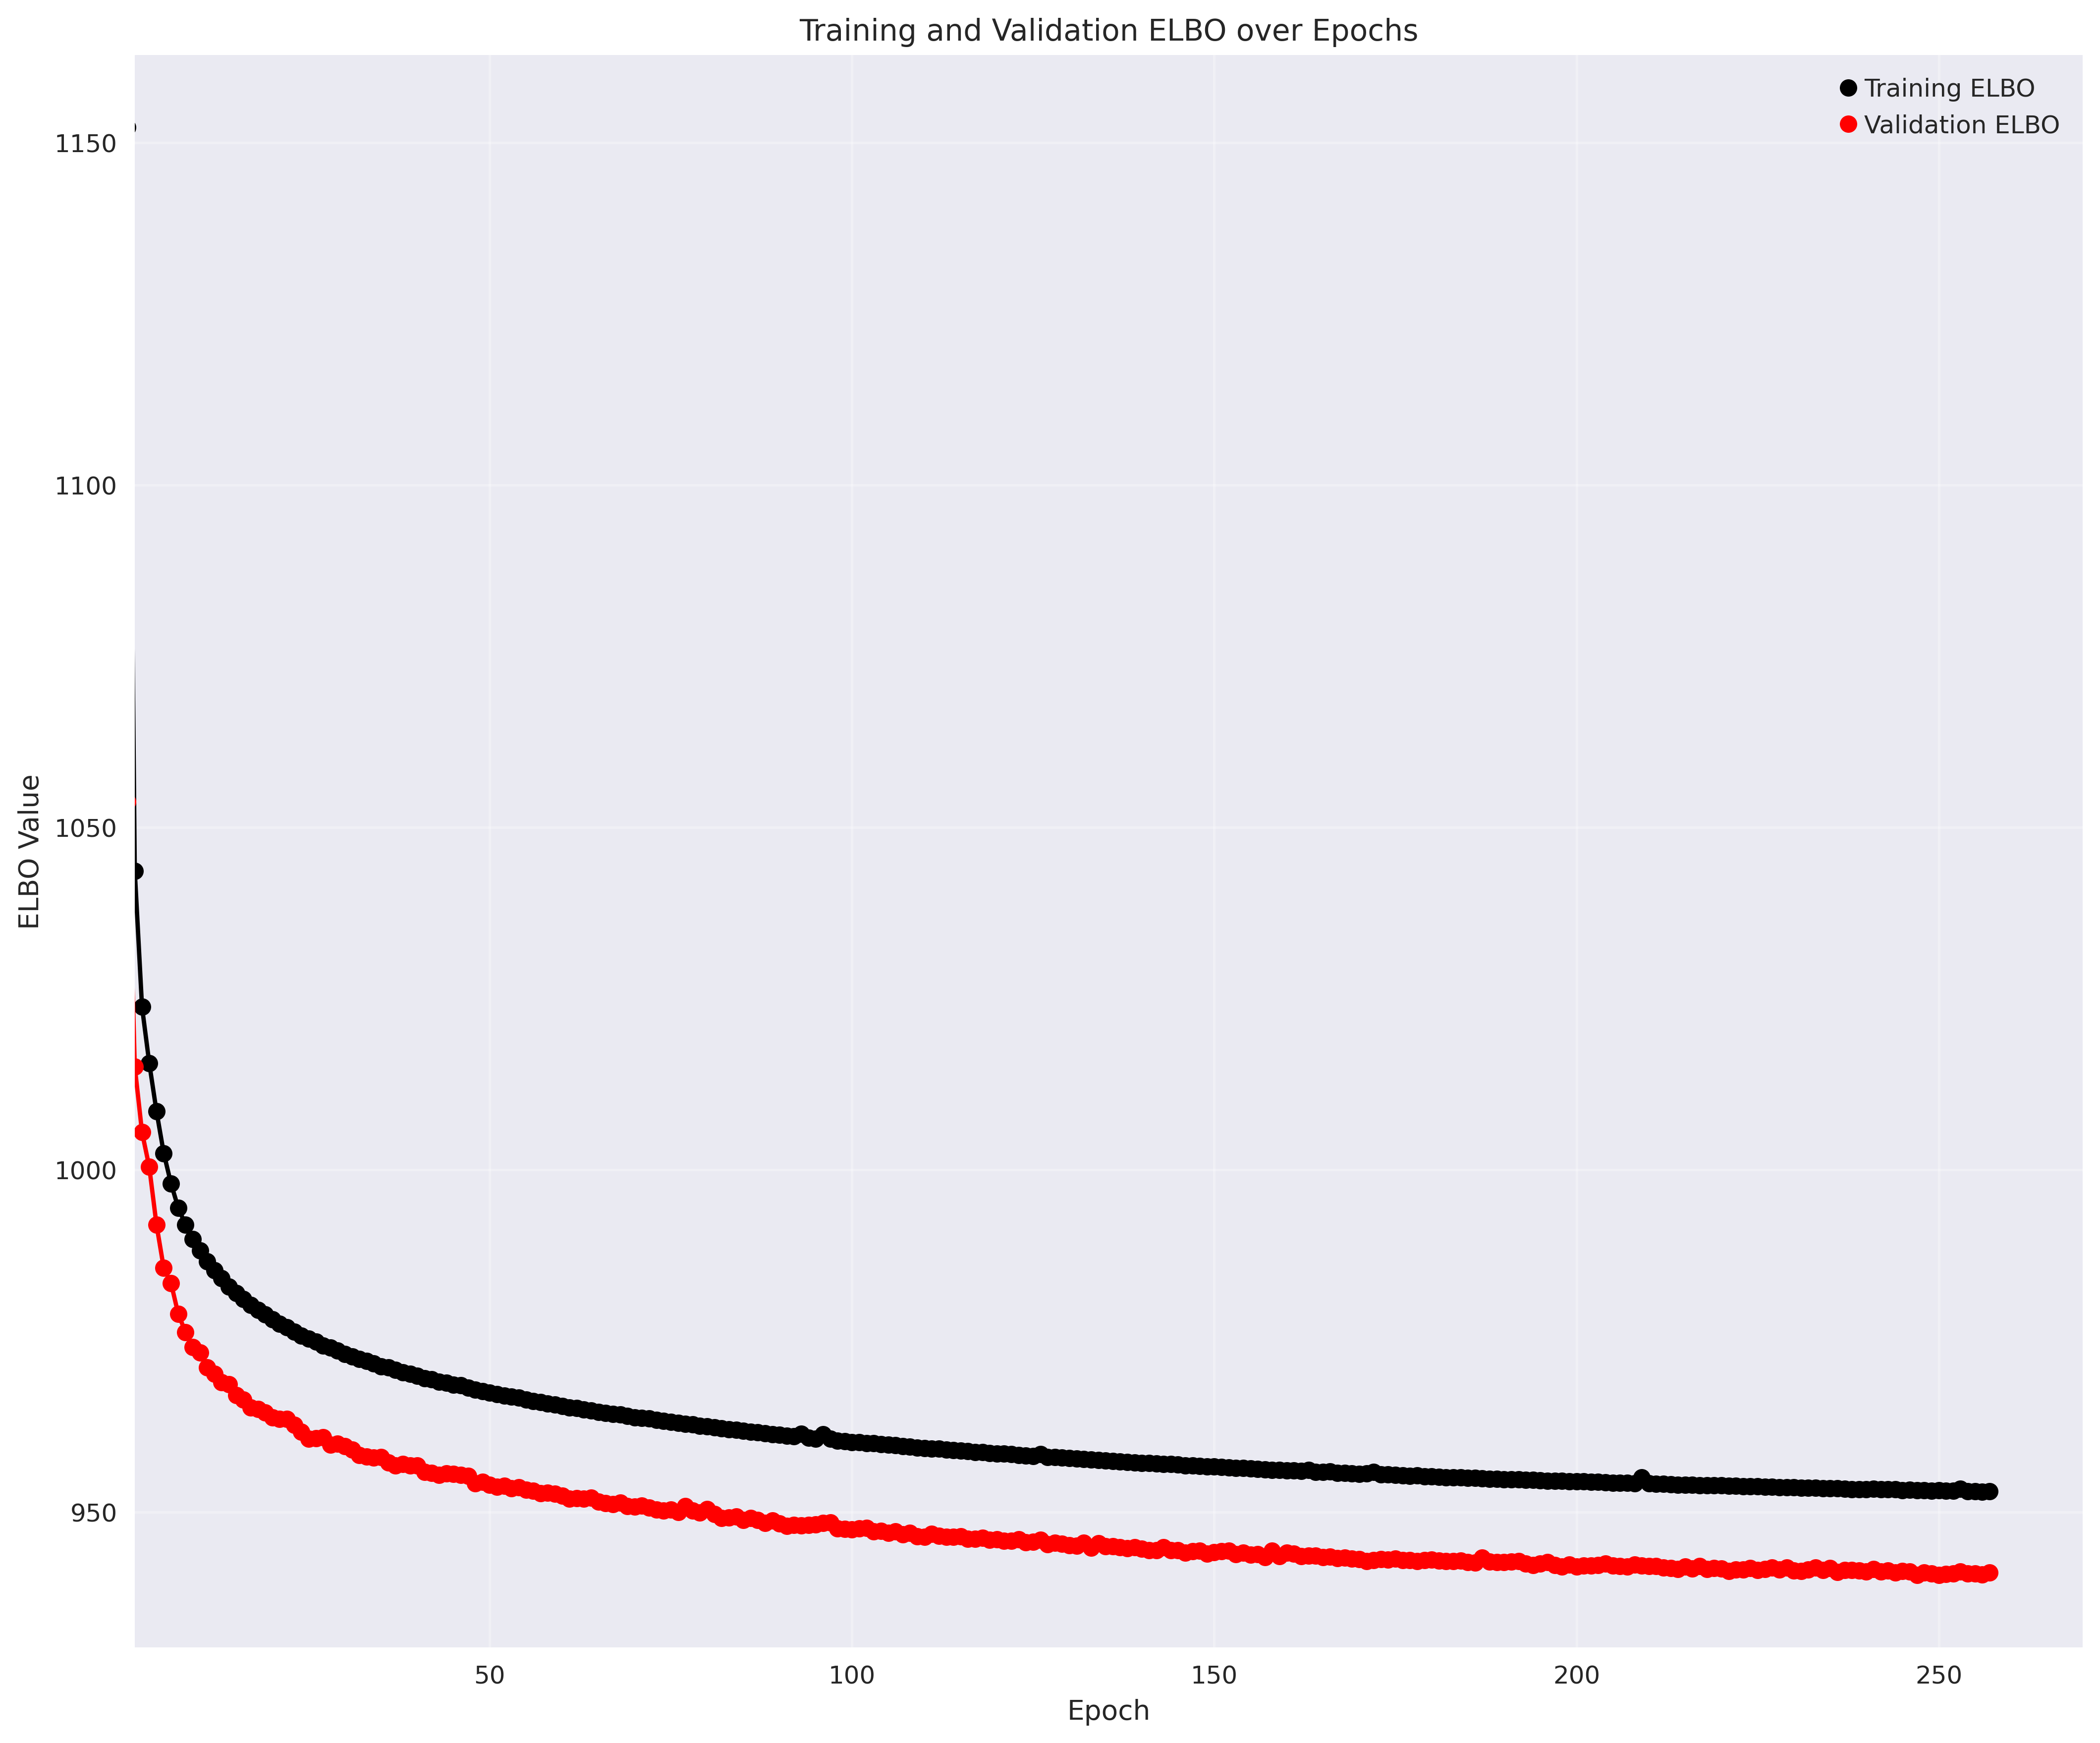

In [19]:
plt.style.use('seaborn')
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_data/scvi_model_{timestamp}/scvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

#### Label transfer with `scANVI` 

In [20]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [21]:
scanvi_model.train(600, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True,
                   accelerator = "gpu",
                   devices = [0])

INFO     Training for 600 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/600 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 943.536. Signaling Trainer to stop.


In [22]:
adata.obs["C_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [23]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [24]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

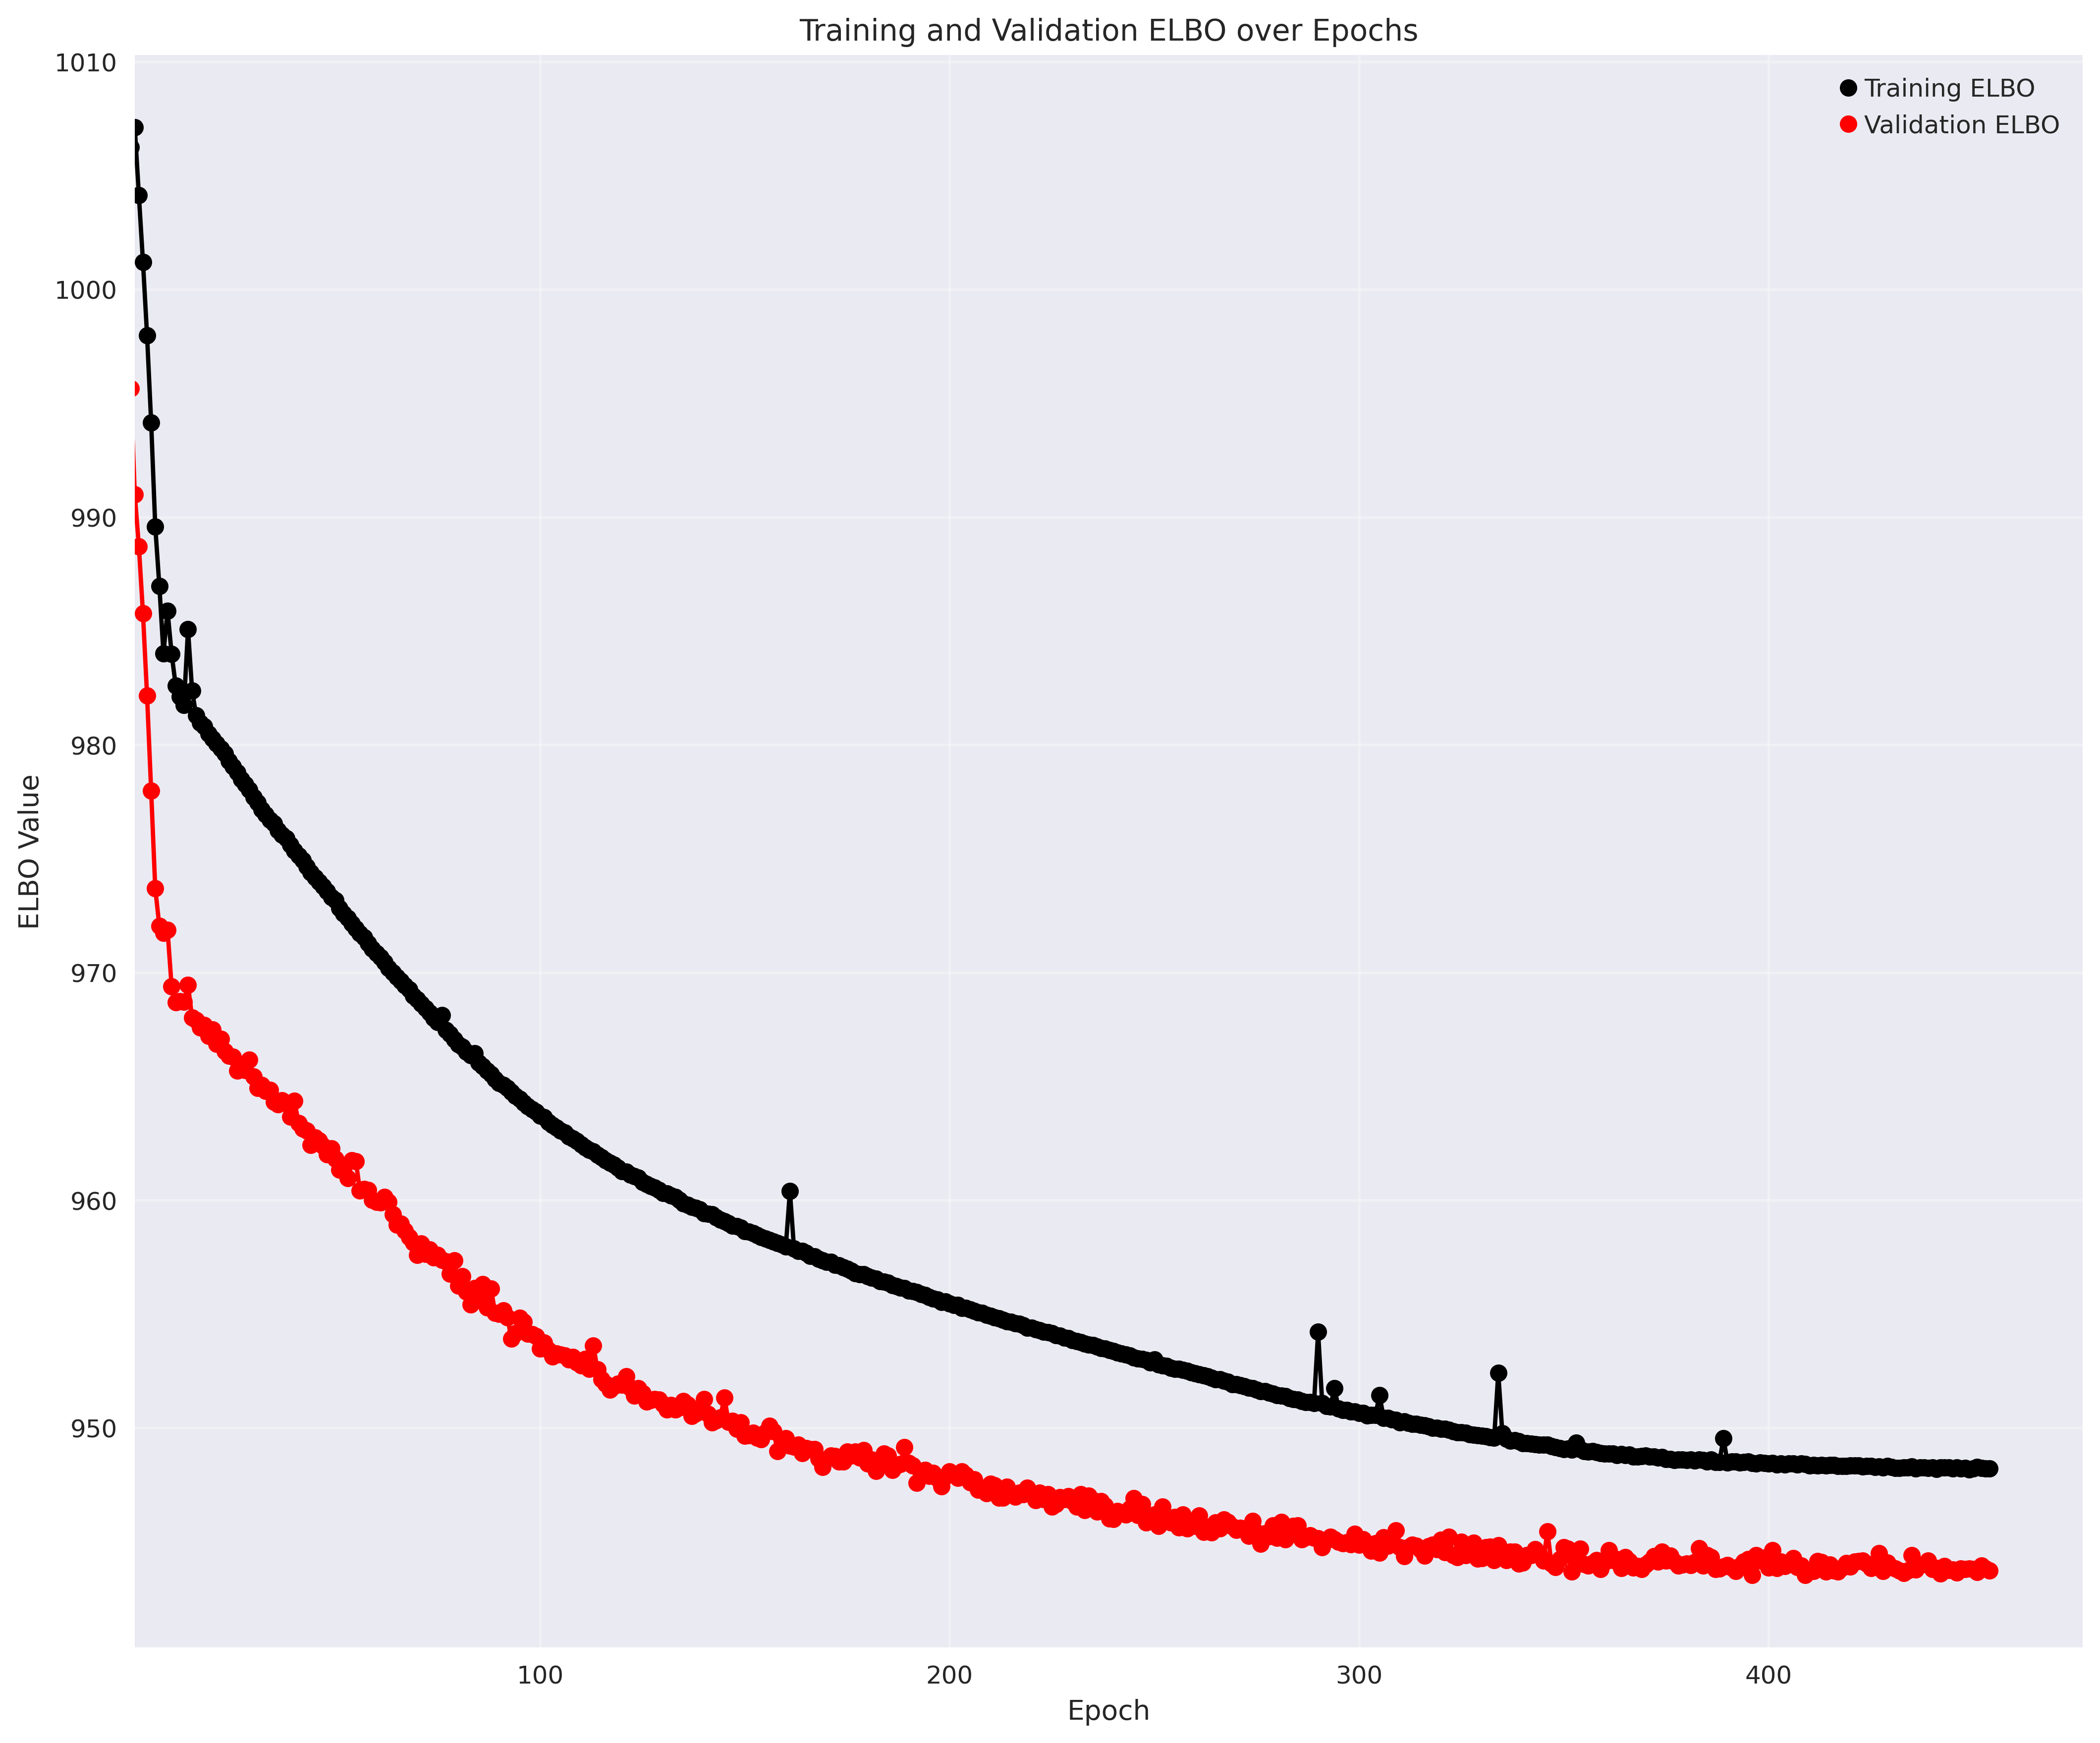

In [ ]:
plt.style.use('seaborn')
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_data/scanvi_model_{timestamp}/scanvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

In [26]:
current_history = adata.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted 5000 hvg (batch ArrayExpress_ID), predicted cell types using scVI-scANVI, scvi params: batch = sample_id and ArrayExpress_ID, n_latent = 15, n_hidden = 128, n_layers = 2, dropout_rate = 0.1, dispersion = gene-batch, gene_likelihood = nb, 258 epochs, scanvi params: 600 epochs',
})
current_history.append(new_entry)

adata.uns['processing_history'] = current_history

In [27]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = '5000hvg'
atribute = 'all_datasets_scVI_scANVI_celltypes'

adata.write_h5ad(f"integration_of_remapped_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [28]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [29]:
confidence_scores = posterior_probs.max(axis=1)

In [30]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [31]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.2, spread = 2, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:02:17)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:03:45)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'metadata_cluster', 'age_group'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['organism_part', 'developmental_stage', 'library_preparation_protocol', 'immunophenotype'], ncols=2, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'developmental_stage', 'full_age', 'growth_condition'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sampling_site', 'Material Type', 'donor_id'], ncols=2, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_categorical_values4_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["C_scANVI", "confidence_score", 'category'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_scANVI_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_continious_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/celltype_transfer_continious2_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

## Save prepared dataset

In [39]:
adata_export = anndata.AnnData(X = adata_raw.X, obs = adata.obs, var = adata_raw.var, uns = adata.uns, obsm = adata.obsm, varm = adata.varm)

In [40]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_celltypes'

adata_export.write_h5ad(f"integration_of_remapped_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")